In [19]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpyro as npr
import numpyro.distributions as dist
import corner
from numpyro.infer import MCMC, NUTS
from scipy.special import roots_legendre
from jax.scipy.stats import gaussian_kde
from numpyro.handlers import condition # for fixing parameters in model

In [20]:
def nth_order_quad(n=20):
    xval, weights = map(jnp.array, roots_legendre(n))
    xval = xval.reshape(-1, 1)
    weights = weights.reshape(-1, 1)

    def integrate(func, a, b, args=()):
        # Integrate function with args from a to b
        return 0.5 * (b - a) * jnp.sum(
            weights * func(0.5 * ((b - a) * xval + (b + a)), *args),
            axis=0
        )

    return integrate
quad = nth_order_quad() # jax compatible quad function for integration


#functions for calculating beta
def E(z, w, OmM):
    return jnp.sqrt(OmM*(1+z)**3 + (1-OmM)*(1+z)**(3*(1+w)))

def integral(z_i, z_j, w, OmM):
    integrant = lambda z: 1.0 / E(z, w, OmM)
    return quad(integrant, z_i, z_j)

def b(z_l, z_s1, z_s2, w, OmM):
    return (integral(z_l, z_s1, w, OmM)*integral(0, z_s2, w, OmM)/
            (integral(z_l, z_s2, w, OmM)*integral(0, z_s1, w, OmM))
    )

#for reading DESI data
def read_txt(filename, column):
    data = []
    with open(filename, "r") as f:
        for line in f:
            values = line.strip().split()
            data.append(values[column-1])
    return np.array(data[1:], dtype=float)

In [34]:
w_desi = read_txt("desi/w.chain.1.txt", 3)
OmM_desi = read_txt("desi/w.chain.1.txt", 5)

w_desi_std = np.std(w_desi)
OmM_desi_std = np.std(OmM_desi)

Joint_model takes deterministic reshifts, uniformily samples from w and OmM (hopefully with consistent priors as DESI)

In [22]:
desi_dist = dist.MultivariateNormal(
    jnp.array([jnp.mean(OmM_desi), jnp.mean(w_desi)]),
    jnp.array(jnp.cov(jnp.vstack([OmM_desi, w_desi])))
)

def joint_model(z_l, z_s1, z_s2, measured_beta):
    w   = npr.sample('w',   dist.Uniform(-3, 1))
    OmM = npr.sample('OmM', dist.Uniform(0, 1))

    model_beta = npr.deterministic("b", b(z_l, z_s1, z_s2, w, OmM))

    # O(1) per step, no double-counting — just condition the sampler
    log_desi = desi_dist.log_prob(jnp.array([OmM, w]))
    npr.factor("desi_likelihood_factor", log_desi)

    # measured_beta is precomputed outside, passed in as argument
    measured_error_beta = measured_beta * 0.01
    npr.sample('likelihood', dist.Normal(model_beta, measured_error_beta), obs=measured_beta)

In [29]:
w_sigma = [] # store the sigma of w_a for each s2 value to plot later
OmM_sigma = []
beta_array = []

def run(start: float, end: float, step: float, lens:float=0.222, s1:float=0.609, sample=10000):
    z_l = lens
    z_s1 = s1
    z_s2_range = np.arange(start, end, step)

    if start <= z_s1:
        print("read idiot")
        return

    name = NUTS(joint_model)
    mcmc = MCMC(name, num_warmup=5000, num_samples=sample, num_chains=1)
    key = jax.random.PRNGKey(100)

    for z_s2 in z_s2_range:
        measured_beta = float(jnp.squeeze(b(z_l, z_s1, z_s2, -1.0, 0.3)))
        mcmc.run(key, z_l, z_s1, z_s2, measured_beta)

        # posterior samples are already DESI-conditioned — no reweighting needed
        w_samples   = mcmc.get_samples()['w']
        OmM_samples = mcmc.get_samples()['OmM']

        w_sigma.append(float(jnp.std(w_samples) / w_desi_std))
        OmM_sigma.append(float(jnp.std(OmM_samples) / OmM_desi_std))
        beta_array.append(float(mcmc.get_samples()['b'].mean()))

        fig, ax = plt.subplots(figsize=(10,10))

        desi = corner.hist2d(
            np.array(OmM_desi),
            np.array(w_desi), 
            color = "grey",
            plot_contours=True,
            contour_kwargs={"linewidths": 2, "alpha": 1},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density = False,
            plot_datapoints = False,
            fill_contours=False,
            ax=ax
        )

        joint = corner.hist2d(
            np.array(OmM_samples),
            np.array(w_samples),
            color = "black",
            plot_contours=True,
            contour_kwargs={"linewidths": [2, 2.2, 2.4], "alpha": 1},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density = False,
            plot_datapoints = False,
            fill_contours=False,
            fig=desi,
            ax=ax
        )

        model = corner.hist2d(
            np.array(OmM_samples),
            np.array(w_samples),
            color='blue',
            plot_contours=True,
            contour_kwargs={"linewidths": 2, "alpha": 0.3},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density=False,
            plot_datapoints=False,
            fill_contours=True,
            fig=joint,
            ax=ax
        )


        #plt.suptitle(f'z_l={z_l:.2f}  z_s1={z_s1:.2f}  z_s2={z_s2:.2f}', y=1, fontsize=14)
        ax.set_xlabel(r'$OmM$')
        ax.set_ylabel(r'$w$')
        plt.show()
        plt.close()

sample: 100%|██████████| 15000/15000 [00:02<00:00, 7268.29it/s, 7 steps of size 7.67e-01. acc. prob=0.94]


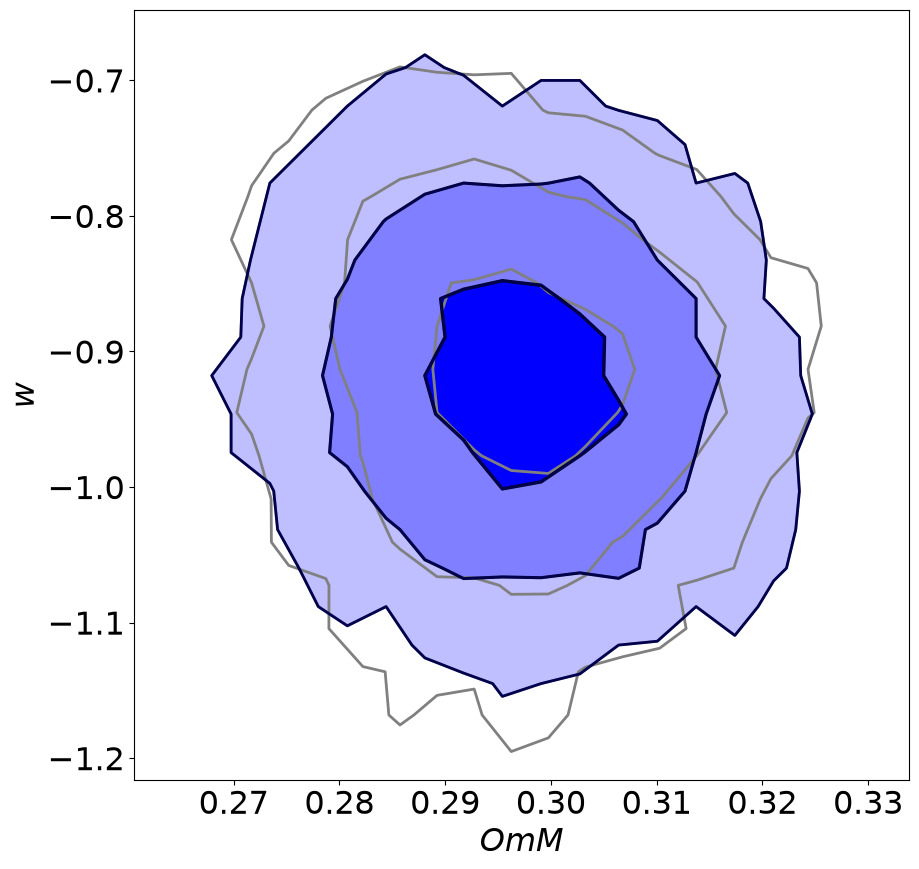

In [30]:
run(2.035, 2.1, 0.2)

In [31]:
axis_range = [(-3.0, 1.0), (-3.0, 2.0)]
def vs2(start:float, end:float, step:float, lens:float = 0.222, s1:float = 0.609, sample = 10000):
    #fixed values throughout this model
    z_l = lens
    z_s1 = s1

    plt.rcParams.update({'font.size': 23})

    z_s2_range = np.arange(start, end, step)

    if start <= z_s1:
        print("read idiot")
        return

    name = NUTS(joint_model)
    mcmc = MCMC(name, num_warmup=5000, num_samples=sample, num_chains=1)
    key = jax.random.PRNGKey(100)

    w_sigma = [] # store the sigma of w_a for each s2 value to plot later
    OmM_sigma = []
    beta_array = []
    

    for z_s2 in z_s2_range:

        mcmc.run(key, z_l, z_s1, z_s2)
        #mcmc.print_summary()

        w_samples = mcmc.get_samples()['w']
        OmM_samples = mcmc.get_samples()['OmM']
        desi_likelihood = mcmc.get_samples()['desi_likelihood'].flatten()
        desi_likelihood = jnp.nan_to_num(desi_likelihood, neginf=-1e10)
        log_weights    = desi_likelihood - jnp.max(desi_likelihood)
        weights        = jnp.exp(log_weights)
        weights        = weights / jnp.sum(weights)

        w_weighted_mean     = jnp.sum(weights * w_samples)
        w_weighted_var      = jnp.sum(weights * (w_samples - w_weighted_mean) ** 2)
        w_weighted_std      = jnp.sqrt(w_weighted_var)
        w_sigma.append(float(w_weighted_std / w_desi_std))

        OmM_weighted_mean   = jnp.sum(weights * OmM_samples)
        OmM_weighted_var    = jnp.sum(weights * (OmM_samples - OmM_weighted_mean) ** 2)
        OmM_weighted_std    = jnp.sqrt(OmM_weighted_var)
        OmM_sigma.append(float(OmM_weighted_std / OmM_desi_std))
        
        beta_array.append(float(mcmc.get_samples()['b'].mean()))

        fig, ax = plt.subplots(figsize=(7,7))

        desi = corner.hist2d(
            np.array(OmM_desi),
            np.array(w_desi), 
            color = "grey",
            plot_contours=True,
            contour_kwargs={"linewidths": 2, "alpha": 1},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density = False,
            plot_datapoints = False,
            fill_contours=False,
            range=axis_range,
            ax=ax
        )

        joint = corner.hist2d(
            np.array(OmM_samples),
            np.array(w_samples),
            color = "black",
            plot_contours=True,
            contour_kwargs={"linewidths": [2, 2.2, 2.4], "alpha": 1},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density = False,
            plot_datapoints = False,
            fill_contours=False,
            weights=desi_likelihood,
            range=axis_range,
            fig=desi,
            ax=ax
        )

        model = corner.hist2d(
            np.array(OmM_samples),
            np.array(w_samples),
            color='blue',
            plot_contours=True,
            contour_kwargs={"linewidths": 2, "alpha": 0.3},
            levels=[0.3935, 0.8647, 0.9889],
            plot_density=False,
            plot_datapoints=False,
            fill_contours=True,
            range=axis_range,
            fig=joint,
            ax=ax
        )


        #plt.suptitle(f'z_l={z_l:.2f}  z_s1={z_s1:.2f}  z_s2={z_s2:.2f}', y=1, fontsize=14)
        ax.set_xlabel(r'$OmM$')
        ax.set_ylabel(r'$w$')
        plt.savefig(f"hist_z2={z_s2:.2f}.png")
        plt.close()


        plt.hist(w_desi, bins=30, density=True, alpha=0.5, color='black', label='w_0 samples')
        plt.suptitle(f'w_a distribution for z_s2={z_s2:.2f}', y=1, fontsize=14)
        plt.savefig(f"w0_s2={z_s2:.3f}.png")
        plt.close()


    plt.plot(beta_array, w_sigma)
    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\sigma_{w,DESI+DSPL}/\sigma_{DESI}$")
    plt.savefig(f"beta_vs_sigma,zs2={start}-{end}.png")
    plt.close()

    plt.plot(beta_array, OmM_sigma)
    plt.xlabel(r"$\beta$")
    plt.ylabel(r"$\sigma_{OmM,DESI+DSPL}/\sigma_{DESI}$")
    plt.savefig(f"beta_vs_sigmaw0,zs2={start}-{end}.png")
    plt.close()

    print(beta_array)
    print(w_sigma)
    print(OmM_sigma)



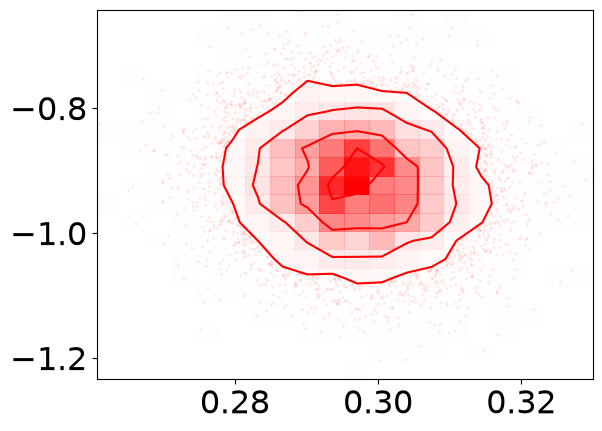

In [33]:
import numpy as np
test_samples = desi_dist.sample(jax.random.PRNGKey(0), (10000,))
corner.hist2d(np.array(test_samples[:,0]), np.array(test_samples[:,1]), color='red')